In [1]:
%matplotlib widget

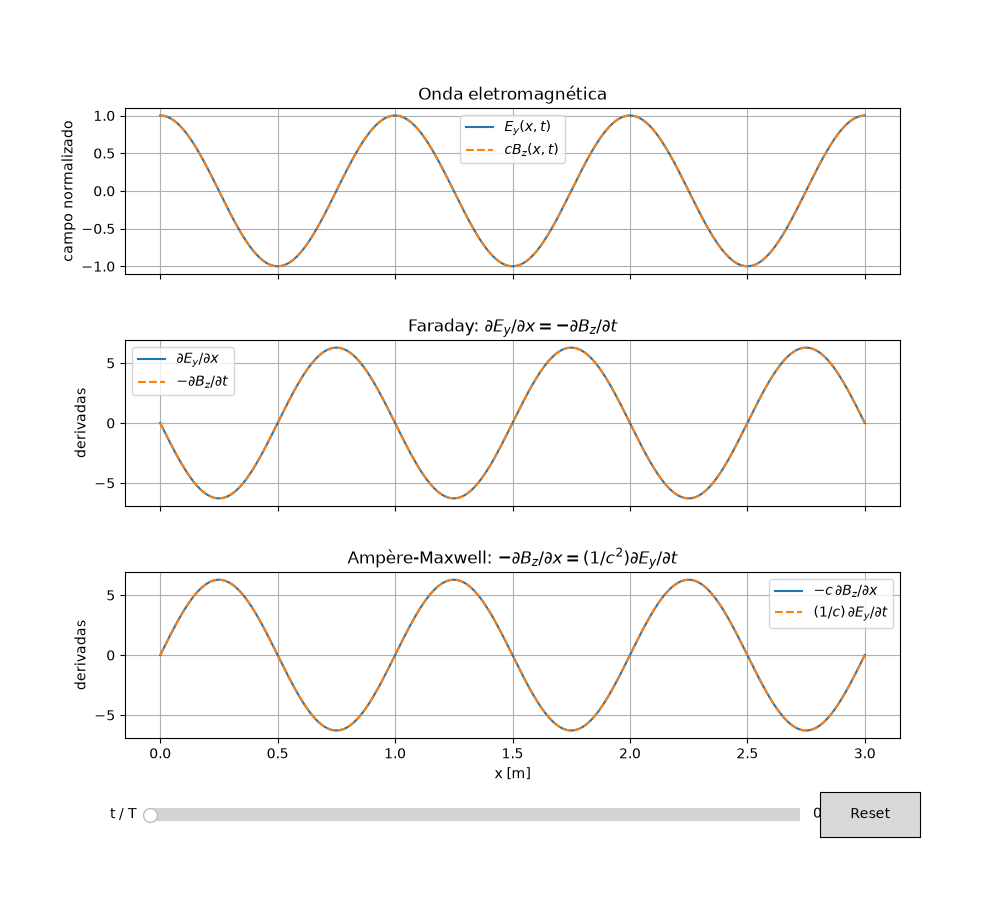

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button

# ============================================================
# Parâmetros da onda
# ============================================================

c = 3.0e8                  # velocidade da luz [m/s]
wavelength = 1.0           # comprimento de onda [m]
E0 = 1.0                   # amplitude de E (normalizada)

k = 2 * np.pi / wavelength
omega = c * k

B0 = E0 / c

# Espaço mostrado: 3 comprimentos de onda
x = np.linspace(0, 3 * wavelength, 1000)

# Usaremos tempo em unidades do período
T = 2 * np.pi / omega


# ============================================================
# Campos e derivadas
# ============================================================

def fields(t):
    phase = k*x - omega*t

    E = E0 * np.cos(phase)
    B = B0 * np.cos(phase)

    # Faraday
    dE_dx = -k * E0 * np.sin(phase)
    minus_dB_dt = -omega * B0 * np.sin(phase)

    # Ampère-Maxwell
    minus_dB_dx = k * B0 * np.sin(phase)
    inv_c2_dE_dt = (omega * E0 / c**2) * np.sin(phase)

    return E, B, dE_dx, minus_dB_dt, minus_dB_dx, inv_c2_dE_dt


# ============================================================
# Figura
# ============================================================

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    figsize=(10, 9),
    sharex=True
)

plt.subplots_adjust(bottom=0.18, hspace=0.40)

# estado inicial
t = 0
E, B, dE_dx, minus_dB_dt, minus_dB_dx, inv_c2_dE_dt = fields(t)


# ------------------------------------------------------------
# Painel 1: campos
# ------------------------------------------------------------

line_E, = ax1.plot(
    x, E,
    label=r"$E_y(x,t)$"
)

line_B, = ax1.plot(
    x, c*B,
    "--",
    label=r"$cB_z(x,t)$"
)

ax1.set_ylabel("campo normalizado")
ax1.set_title("Onda eletromagnética")
ax1.legend()
ax1.grid()


# ------------------------------------------------------------
# Painel 2: Lei de Faraday
# ------------------------------------------------------------

line_dE_dx, = ax2.plot(
    x,
    dE_dx,
    label=r"$\partial E_y/\partial x$"
)

line_minus_dB_dt, = ax2.plot(
    x,
    minus_dB_dt,
    "--",
    label=r"$-\partial B_z/\partial t$"
)

ax2.set_ylabel("derivadas")
ax2.set_title(
    r"Faraday: $\partial E_y/\partial x = -\partial B_z/\partial t$"
)
ax2.legend()
ax2.grid()


# ------------------------------------------------------------
# Painel 3: Ampère-Maxwell
#
# Multiplico ambos por c apenas para colocá-los
# em uma escala visual conveniente.
# ------------------------------------------------------------

line_minus_dB_dx, = ax3.plot(
    x,
    c * minus_dB_dx,
    label=r"$-c\,\partial B_z/\partial x$"
)

line_dE_dt, = ax3.plot(
    x,
    c * inv_c2_dE_dt,
    "--",
    label=r"$(1/c)\,\partial E_y/\partial t$"
)

ax3.set_xlabel("x [m]")
ax3.set_ylabel("derivadas")
ax3.set_title(
    r"Ampère-Maxwell: "
    r"$-\partial B_z/\partial x=(1/c^2)\partial E_y/\partial t$"
)
ax3.legend()
ax3.grid()


# ============================================================
# Slider de tempo
# ============================================================

slider_ax = plt.axes([0.15, 0.08, 0.65, 0.03])

time_slider = Slider(
    slider_ax,
    "t / T",
    0.0,
    2.0,
    valinit=0.0
)


def update(value):

    t = time_slider.val * T

    (
        E,
        B,
        dE_dx,
        minus_dB_dt,
        minus_dB_dx,
        inv_c2_dE_dt
    ) = fields(t)

    line_E.set_ydata(E)
    line_B.set_ydata(c * B)

    line_dE_dx.set_ydata(dE_dx)
    line_minus_dB_dt.set_ydata(minus_dB_dt)

    line_minus_dB_dx.set_ydata(c * minus_dB_dx)
    line_dE_dt.set_ydata(c * inv_c2_dE_dt)

    fig.canvas.draw_idle()


time_slider.on_changed(update)


# ============================================================
# Botão reset
# ============================================================

reset_ax = plt.axes([0.82, 0.07, 0.10, 0.05])
reset_button = Button(reset_ax, "Reset")

def reset(event):
    time_slider.reset()

reset_button.on_clicked(reset)

plt.show()

# Equações implementadas na animação

A animação representa uma onda eletromagnética plana no vácuo propagando-se na direção $+x$.

Escolhemos a orientação

$$
\mathbf{k}=k\hat{x},
\qquad
\mathbf{E}=E_y\hat{y},
\qquad
\mathbf{B}=B_z\hat{z}.
$$

Portanto,

$$
\mathbf{E}\perp\mathbf{B}\perp\mathbf{k}.
$$

## Equações de Maxwell no vácuo

Na ausência de cargas e correntes, as duas equações de Maxwell responsáveis pelo acoplamento entre os campos são

$$
\nabla\times\mathbf{E}
=
-\frac{\partial\mathbf{B}}{\partial t}
$$

e

$$
\nabla\times\mathbf{B}
=
\frac{1}{c^2}\frac{\partial\mathbf{E}}{\partial t}.
$$

Para a geometria escolhida,

$$
\mathbf{E}=E_y(x,t)\hat{y}
$$

e

$$
\mathbf{B}=B_z(x,t)\hat{z},
$$

essas equações reduzem-se a

$$
\frac{\partial E_y}{\partial x}
=
-\frac{\partial B_z}{\partial t}
$$

e

$$
-\frac{\partial B_z}{\partial x}
=
\frac{1}{c^2}\frac{\partial E_y}{\partial t}.
$$

São essas duas relações que determinam como $E$ e $B$ estão acoplados.

---

## Solução utilizada no código

O código utiliza uma solução de onda plana:

$$
E_y(x,t)
=
E_0\cos(kx-\omega t)
$$

e

$$
B_z(x,t)
=
\frac{E_0}{c}\cos(kx-\omega t).
$$

Portanto,

$$
E_0=cB_0.
$$

A fase comum aos dois campos é

$$
\phi(x,t)=kx-\omega t.
$$

---

## Verificação da primeira equação de Maxwell

Partindo de

$$
E_y(x,t)
=
E_0\cos(kx-\omega t),
$$

temos

$$
\frac{\partial E_y}{\partial x}
=
-kE_0\sin(kx-\omega t).
$$

Para o campo magnético,

$$
B_z(x,t)
=
\frac{E_0}{c}\cos(kx-\omega t),
$$

temos

$$
\frac{\partial B_z}{\partial t}
=
\frac{\omega E_0}{c}\sin(kx-\omega t).
$$

Portanto,

$$
-\frac{\partial B_z}{\partial t}
=
-\frac{\omega E_0}{c}\sin(kx-\omega t).
$$

A equação

$$
\frac{\partial E_y}{\partial x}
=
-\frac{\partial B_z}{\partial t}
$$

é satisfeita se

$$
kE_0
=
\frac{\omega E_0}{c},
$$

isto é,

$$
\boxed{\omega=ck}.
$$

---

## Verificação da segunda equação de Maxwell

Para o campo magnético,

$$
\frac{\partial B_z}{\partial x}
=
-\frac{kE_0}{c}\sin(kx-\omega t),
$$

portanto

$$
-\frac{\partial B_z}{\partial x}
=
\frac{kE_0}{c}\sin(kx-\omega t).
$$

Para o campo elétrico,

$$
\frac{\partial E_y}{\partial t}
=
\omega E_0\sin(kx-\omega t).
$$

Logo,

$$
\frac{1}{c^2}\frac{\partial E_y}{\partial t}
=
\frac{\omega E_0}{c^2}\sin(kx-\omega t).
$$

A equação

$$
-\frac{\partial B_z}{\partial x}
=
\frac{1}{c^2}\frac{\partial E_y}{\partial t}
$$

é satisfeita se

$$
\frac{k}{c}
=
\frac{\omega}{c^2},
$$

novamente resultando em

$$
\boxed{\omega=ck}.
$$

Assim, as duas equações de Maxwell são satisfeitas pela solução implementada.

---

## Correspondência direta com o código

O comprimento de onda é escolhido como $\lambda=1$ e o número de onda é calculado por

$$
\boxed{k=\frac{2\pi}{\lambda}}.
$$

No código:

```python
k = 2 * np.pi / wavelength
```

A relação de dispersão exigida pelas equações de Maxwell é

$$
\boxed{\omega=ck}.
$$

No código:

```python
omega = c * k
```

O período segue de

$$
\omega=\frac{2\pi}{T},
$$

portanto

$$
\boxed{T=\frac{2\pi}{\omega}}.
$$

No código:

```python
T = 2 * np.pi / omega
```

A fase da onda é

$$
\boxed{\phi(x,t)=kx-\omega t}.
$$

No código:

```python
phase = k*x - omega*t
```

O campo elétrico é

$$
\boxed{
E_y(x,t)=E_0\cos(kx-\omega t)
}.
$$

No código:

```python
E = E0 * np.cos(phase)
```

O campo magnético físico é

$$
\boxed{
B_z(x,t)=\frac{E_0}{c}\cos(kx-\omega t)
}.
$$

Como $B$ possui uma escala numérica muito menor que $E$ em unidades SI, a animação representa $cB$:

$$
cB_z(x,t)
=
E_0\cos(kx-\omega t).
$$

No código:

```python
cB = E0 * np.cos(phase)
```

Portanto, o código não está simulando numericamente as equações de Maxwell passo a passo. Ele está animando uma **solução analítica** dessas equações:

$$
\boxed{
\begin{aligned}
E_y(x,t) &= E_0\cos(kx-\omega t),\\
B_z(x,t) &= \frac{E_0}{c}\cos(kx-\omega t),
\end{aligned}
}
$$

com

$$
\boxed{\omega=ck}.
$$

A condição $\omega=ck$ é justamente o que faz essa solução satisfazer simultaneamente as duas equações de Maxwell e propagar-se no vácuo com velocidade

$$
\boxed{
v=\frac{\omega}{k}=c.
}
$$

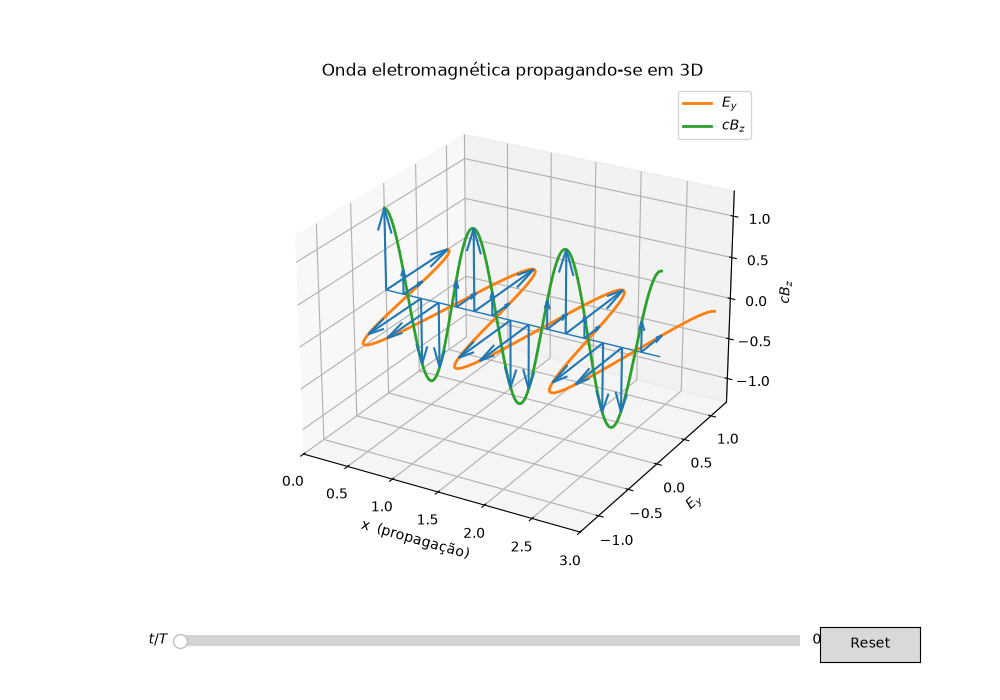

In [3]:
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ============================================================
# Parâmetros físicos
# ============================================================

c = 3.0e8
wavelength = 1.0
E0 = 1.0

k = 2 * np.pi / wavelength
omega = c * k
T = 2 * np.pi / omega

# espaço
x = np.linspace(0, 3 * wavelength, 300)

# ============================================================
# Campo eletromagnético
# ============================================================

def fields(t):
    phase = k*x - omega*t

    E = E0 * np.cos(phase)

    # uso cB para ter mesma escala/unidade visual que E
    cB = E0 * np.cos(phase)

    return E, cB


# ============================================================
# Figura
# ============================================================

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

plt.subplots_adjust(bottom=0.18)

# tempo inicial
t0 = 0.0
E, cB = fields(t0)

# eixo de propagação
ax.plot(
    x,
    np.zeros_like(x),
    np.zeros_like(x),
    linewidth=1
)

# Campo elétrico:
# x = propagação
# y = E
# z = 0
line_E, = ax.plot(
    x,
    E,
    np.zeros_like(x),
    linewidth=2,
    label=r"$E_y$"
)

# Campo magnético:
# x = propagação
# y = 0
# z = cB
line_B, = ax.plot(
    x,
    np.zeros_like(x),
    cB,
    linewidth=2,
    label=r"$cB_z$"
)

# ============================================================
# Setas vetoriais ao longo da onda
# ============================================================

sample_idx = np.arange(0, len(x), 20)

quiver_E = None
quiver_B = None

def draw_vectors(E, cB):
    global quiver_E, quiver_B

    if quiver_E is not None:
        quiver_E.remove()

    if quiver_B is not None:
        quiver_B.remove()

    xs = x[sample_idx]

    # E aponta na direção y
    quiver_E = ax.quiver(
        xs,
        np.zeros_like(xs),
        np.zeros_like(xs),
        np.zeros_like(xs),
        E[sample_idx],
        np.zeros_like(xs),
        length=1,
        normalize=False
    )

    # B aponta na direção z
    quiver_B = ax.quiver(
        xs,
        np.zeros_like(xs),
        np.zeros_like(xs),
        np.zeros_like(xs),
        np.zeros_like(xs),
        cB[sample_idx],
        length=1,
        normalize=False
    )


draw_vectors(E, cB)

# ============================================================
# Aparência
# ============================================================

ax.set_xlim(0, 3*wavelength)
ax.set_ylim(-1.3, 1.3)
ax.set_zlim(-1.3, 1.3)

ax.set_xlabel("x  (propagação)")
ax.set_ylabel(r"$E_y$")
ax.set_zlabel(r"$cB_z$")

ax.set_title("Onda eletromagnética propagando-se em 3D")

ax.legend()

ax.view_init(
    elev=25,
    azim=-60
)

# ============================================================
# Slider de tempo
# ============================================================

slider_ax = plt.axes([0.18, 0.07, 0.62, 0.03])

time_slider = Slider(
    slider_ax,
    r"$t/T$",
    0.0,
    2.0,
    valinit=0.0,
    valstep=0.01
)

def update(val):
    t = time_slider.val * T

    E, cB = fields(t)

    # atualiza E
    line_E.set_data_3d(
        x,
        E,
        np.zeros_like(x)
    )

    # atualiza B
    line_B.set_data_3d(
        x,
        np.zeros_like(x),
        cB
    )

    draw_vectors(E, cB)

    fig.canvas.draw_idle()

time_slider.on_changed(update)

# ============================================================
# Reset
# ============================================================

reset_ax = plt.axes([0.82, 0.055, 0.10, 0.05])
reset_button = Button(reset_ax, "Reset")

def reset(event):
    time_slider.reset()

reset_button.on_clicked(reset)

plt.show()